In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [145]:
from experiment_modules import *
from scipy.optimize import curve_fit
from numpy.testing import assert_array_equal
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

from copy import deepcopy
from rich.progress import track

In [63]:
rng = jax.random.PRNGKey(0)
generator = Generator(5000)

In [121]:
def calculate_entropy_from_model(state, generator=generator):
    """
    Compute the entropy of a model on some data.
    """
    ntk_fn = get_ntk_function(state.apply_fn, None)

    ntk_matrix = ntk_fn(
                    generator.train_ds["inputs"],
                    generator.train_ds["inputs"],
                    {"params": state.params}
                )

    return compute_entropy(ntk_matrix), ntk_matrix

In [166]:
def compute_mp_distribution(lambdas, sigma, q):

    lambda_max = sigma * (1 + np.sqrt(q)) ** 2
    lambda_min = sigma * (1 - np.sqrt(q)) ** 2
    
    large_diff = lambda_max - lambdas
    small_diff = lambdas - lambda_min
    
    rho = (jnp.sqrt(large_diff * small_diff)) / (2 * jnp.pi * q * sigma * lambdas)
#     rho = jnp.nan_to_num(rho, posinf=0., neginf=0.)
        
    return rho

In [65]:
width = 2000
rng = jax.random.PRNGKey(68465)

In [66]:
model = build_network(128, 2)()
model_state = create_train_state(model, rng, 1e-3)
entropy, ntk = calculate_entropy_from_model(model_state)

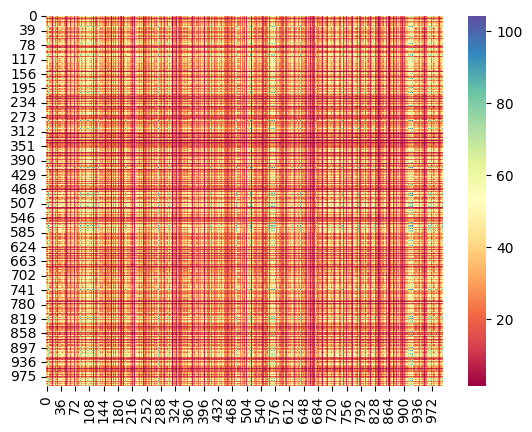

In [67]:
sns.heatmap(
    ntk,
    vmin=None,
    vmax=None,
    cmap="Spectral",
)
plt.show()

# Denoising

In [71]:
eigs, vals = np.linalg.eigh(ntk)

In [123]:
density = compute_mp_distribution(eigs, 8000, 1.)

/tmp/ipykernel_68313/3112245752.py:9: RuntimeWarning: invalid value encountered in sqrt
  rho = (np.sqrt(large_diff * small_diff)) / (2 * np.pi * q * sigma * lambdas)
/tmp/ipykernel_68313/3112245752.py:13: RuntimeWarning: invalid value encountered in sqrt
  return (np.sqrt(large_diff * small_diff)) / (2 * np.pi * q * sigma * lambdas)


In [169]:
true_density, true_bins = np.histogram(eigs, bins=500)
true_density = jnp.array(true_density)
true_bins = jnp.array(true_bins)

In [167]:
popt, pconv = curve_fit(compute_mp_distribution, true_bins[:-1], true_density)

In [173]:
params = np.array([1., 1.])
lr = 0.01

def compute_loss(s_, q_):
    predictions = compute_mp_distribution(true_bins[:-1], s_, q_)
    
    loss = jnp.linalg.norm(predictions - true_density, ord=2)

    return loss.mean()

grad_fn = jax.grad(compute_loss)

for _ in range(10):
    
    grads = grad_fn(*params)
    print(grads)
    
    params -= lr * grads


nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [157]:
params

Array([nan, nan], dtype=float32)

In [ ]:
sns.histplot(eigs, stat="density", bins=500)
plt.plot(eigs, density)
plt.yscale("log")

In [47]:
ssquare = 1.
q = 0.2

lambda_max = ssquare * (1 + np.sqrt(q)) ** 2
lambda_min = ssquare * (1 - np.sqrt(q)) ** 2

lambdas = np.linspace(lambda_min, lambda_max, 500)

large_diff = lambda_max - lambdas
small_diff = lambdas - lambda_min

rho = (np.sqrt(large_diff * small_diff)) / (2 * np.pi * q * ssquare * lambdas)

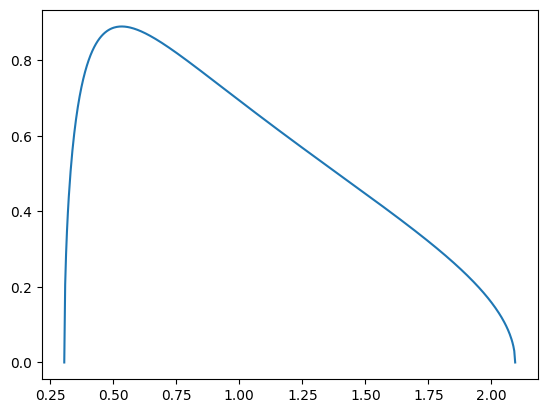

In [48]:
plt.plot(lambdas, rho)